In [1]:
import json
import re
from utils.gait_parameters_extractor_raw import (
    GaitParametersExtractorRaw,
    CoordinatesIdx,
)

datasets_parameters = {
 'mocap': 'datasets/mocap/calculated_parameters_v3.json',
    
 'openpose': 'datasets/openpose/calculated_parameters_openpose_triangulated_v2.json',
    
 'mediapipe': 'datasets/mediapipe/calculated_parameters_v4_triangulated.json',
    
 'hrnet': 'datasets/mmpose/calculated_parameters_hrnet_triangulated.json',
 'rtmpose': 'datasets/mmpose/calculated_parameters_rtmpose_triangulated.json',
 'vitpose': 'datasets/mmpose/calculated_parameters_vitpose_triangulated.json',
    
 'movenet_lightning': 'datasets/movenet/calculated_parameters_lightning_triangulated.json',
 'movenet_thunder': 'datasets/movenet/calculated_parameters_thunder_triangulated.json',
    
 'yolo_v26': 'datasets/yolo/calculated_parameters_v3_yolo26.json',
 'yolo_v11': 'datasets/yolo/calculated_parameters_v2_triangulated_v3.json'
}

parameter_names = ['legs_angles', 'left_knee_angles', 'right_knee_angles', 'left_hip_angles', 'right_hip_angles', 
                   'left_humerus_angles', 'right_humerus_angles', 'left_elbow_angles', 'right_elbow_angles', 
                   'ankle_distances', 'knee_distances', 'elbow_distances', 'hand_distances', 
                   'center_of_gravity_height_change', 'lateral_pelvic_tilt', 'pelvis_rotation']

with open(datasets_parameters["mocap"], "r") as file:
    sequence_cycles = json.load(file)

In [2]:
sequence_cycles['p1s1'].keys()

dict_keys(['legs_angles', 'left_knee_angles', 'right_knee_angles', 'left_hip_angles', 'right_hip_angles', 'left_humerus_angles', 'right_humerus_angles', 'left_elbow_angles', 'right_elbow_angles', 'ankle_distances', 'knee_distances', 'elbow_distances', 'hand_distances', 'center_of_gravity_height_change', 'lateral_pelvic_tilt', 'pelvis_rotation'])

In [3]:
import random
import torch
import re
import json
import math
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from typing import Sequence, Mapping, Literal
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.base import TransformerMixin

def get_identifiers_from_seq_key(sequence_key: str) -> tuple[int, int]:
    match = re.search(r"p(\d+)s(\d+)", sequence_key)

    if match:
        person_id = int(match.group(1))
        sequence_id = int(match.group(2))
        return person_id, sequence_id
    else:
        raise Exception(
            f"Identifiers cannot be extracted from provided key ({sequence_key})"
        )


def get_scaler_by_sequence(
    data_file: str,
    selected_sequences: Sequence[int],
) -> TransformerMixin:
    """
    Function prepare standard scaler on training set,
    It can be later passed to SiameseGaitDatasetRawMultipleDatasets
    """
    with open(data_file, "r", encoding="utf-8") as file:
        features_ds = json.load(file)

    combined_test_features = {parameter_name: [] for parameter_name in parameter_names}

    for sequence_key, parameters in features_ds.items():
        person_id, sequence_id = get_identifiers_from_seq_key(sequence_key)
        if sequence_id in selected_sequences:
            for parameter_name in parameter_names:
                combined_test_features[parameter_name] += parameters[parameter_name]

    features_df = pd.DataFrame(combined_test_features)

    scaler = StandardScaler()
    scaler.fit(features_df.values)

    return scaler


class SiameseGaitDatasetSingle(Dataset):
    def __init__(
        self,
        selected_sequences: Sequence[int],
        data_file: str,
        scaler: TransformerMixin | None = None,
        sequence_length: int = 32,
        feature_dim: int = 16,
    ):

        self.scaler = scaler
        self.selected_sequences = selected_sequences
        self.features = self._prepare_features(data_file)
        self.sequence_length = sequence_length
        self.feature_dim = feature_dim
        self.data = self._get_steps_features(self.features)

    def _prepare_features(
        self,
        data_file: str,
    ) -> Mapping[str, Mapping[int, np.array]]:

        with open(data_file, "r", encoding="utf-8") as file:
            features_ds = json.load(file)

        return features_ds

    def _find_local_maxima(
        self, data: Sequence[float], window_size: int = 7
    ) -> Sequence[int]:
        local_maxima_indices = []

        for i in range(window_size, len(data) - window_size):
            window_prev = data[i - window_size : i]
            window_next = data[i + 1 : i + window_size + 1]
            current = data[i]

            if current > max(window_prev) and current > max(window_next):
                local_maxima_indices.append(i)

        return local_maxima_indices

    def _get_steps_features(self, dataset):
        data = []
        for sequence_key, sequence_parameters in dataset.items():
            person_id, sequence_id = get_identifiers_from_seq_key(sequence_key)
            if sequence_id in self.selected_sequences:
                maxima = self._find_local_maxima(sequence_parameters["ankle_distances"])
                if len(maxima) % 2:
                    stride_centers = [
                        int(maxima[2 * i] + 0.5 * (maxima[2 * i + 2] - maxima[2 * i]))
                        for i in range(len(maxima) // 2)
                    ]
                else:
                    stride_centers = [
                        int(maxima[2 * i] + 0.5 * (maxima[2 * i + 2] - maxima[2 * i]))
                        for i in range(len(maxima) // 2 - 1)
                    ]
                for c_idx in stride_centers:
                    stride_matrix = np.array(
                        [
                            sequence_parameters[parameter][c_idx - 16 : c_idx + 16]
                            for parameter in parameter_names
                        ]
                    )

                    if self.scaler:
                        data.append((
                            np.array(self.scaler.transform(stride_matrix.T)).astype(
                                np.float32
                            ).T,
                            torch.tensor(int(person_id) - 1)
                        ))
                    else:
                        data.append((
                            stride_matrix.astype(np.float32),
                            torch.tensor(int(person_id) - 1),
                        ))

        return data

    def _to_sequence(self, row):
        """
        Convert flat row -> (X, 32)
        """
        arr = row.values.astype("float32")
        return torch.tensor(
            arr.reshape(self.sequence_length, self.feature_dim),
            dtype=torch.float32,
        )

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)


In [4]:
cloth_1 = [1,2,3,4]
cloth_2 = [5,6,7,8]

scaler = get_scaler_by_sequence(
    data_file = datasets_parameters['mocap'],
    selected_sequences = cloth_1,
)

gd_cloth_1 = SiameseGaitDatasetSingle(
    selected_sequences = cloth_1,
    data_file = datasets_parameters['mocap'],
    scaler = scaler,
)

gd_cloth_2 = SiameseGaitDatasetSingle(
    selected_sequences = cloth_2,
    data_file = datasets_parameters['mocap'],
    scaler = scaler,
)


In [5]:
print(len(gd_cloth_1))
print(len(gd_cloth_2))

335
66


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate_topk(model, dataloader, ks=(1,2,3)):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    max_k = max(ks)

    correct = {k: 0 for k in ks}
    total = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            _, pred = logits.topk(max_k, dim=1, largest=True, sorted=True)

            y = y.view(-1, 1)
            matches = pred.eq(y)

            for k in ks:
                correct[k] += matches[:, :k].any(dim=1).sum().item()

            total += y.size(0)

    return {k: correct[k] / total for k in ks}


def plot_confusion_matrix(model, dataloader, num_classes=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    

    cm = confusion_matrix(all_labels, all_preds, labels=range(32))

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, 
               interpolation='nearest',
               cmap=LinearSegmentedColormap.from_list(
                   "brownish", ["white", "#54290b"]
               ),
    )
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks)
    plt.yticks(tick_marks)

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()

In [7]:
import torch
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, input_size, num_classes=32):
        super(Model, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(), 
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x

In [8]:
import torch
import torch.nn as nn

class ImprovedModel(nn.Module):
    def __init__(self, input_size, num_classes=32):
        super(ImprovedModel, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.SiLU(), 
            nn.MaxPool1d(kernel_size=2), 
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout1d(0.1),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3), 
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x

In [9]:
torch.cuda.is_available()

True

Epoch [1/1000] Train Loss: 3.4585 Train Acc: 0.0485 Val Loss: 3.4709
Epoch [2/1000] Train Loss: 3.4140 Train Acc: 0.0522 Val Loss: 3.4571
Epoch [3/1000] Train Loss: 3.3667 Train Acc: 0.0896 Val Loss: 3.4226
Epoch [4/1000] Train Loss: 3.3414 Train Acc: 0.1082 Val Loss: 3.3826
Epoch [5/1000] Train Loss: 3.3077 Train Acc: 0.1418 Val Loss: 3.3480
Epoch [6/1000] Train Loss: 3.2731 Train Acc: 0.1679 Val Loss: 3.3147
Epoch [7/1000] Train Loss: 3.2162 Train Acc: 0.2127 Val Loss: 3.2906
Epoch [8/1000] Train Loss: 3.1801 Train Acc: 0.2090 Val Loss: 3.2592
Epoch [9/1000] Train Loss: 3.1515 Train Acc: 0.2090 Val Loss: 3.2328
Epoch [10/1000] Train Loss: 3.1048 Train Acc: 0.2612 Val Loss: 3.2001
Epoch [11/1000] Train Loss: 3.0499 Train Acc: 0.2836 Val Loss: 3.1668
Epoch [12/1000] Train Loss: 3.0373 Train Acc: 0.3060 Val Loss: 3.1210
Epoch [13/1000] Train Loss: 2.9608 Train Acc: 0.2948 Val Loss: 3.0857
Epoch [14/1000] Train Loss: 2.9431 Train Acc: 0.2761 Val Loss: 3.0489
Epoch [15/1000] Train Loss: 2

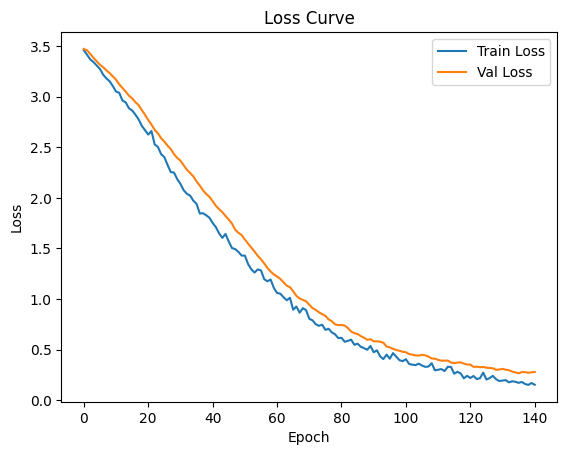

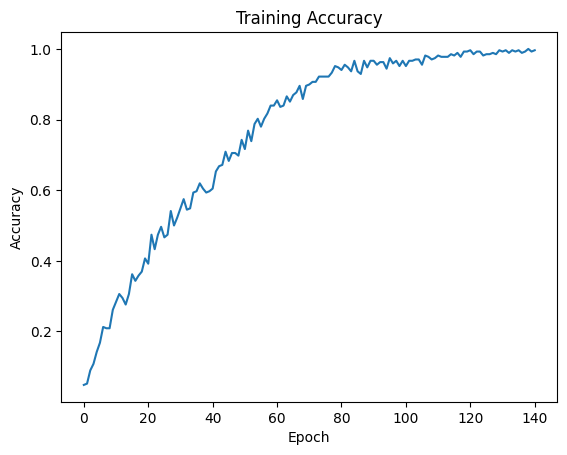

In [19]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch

# dataset_name = "mocap"
dataset_name = "yolo_v26"
cloth_1 = [1,2,3,4]
cloth_2 = [5,6,7,8]

scaler = get_scaler_by_sequence(
    data_file = datasets_parameters[dataset_name],
    selected_sequences = cloth_1,
)

gd_cloth_1 = SiameseGaitDatasetSingle(
    selected_sequences = cloth_1,
    data_file = datasets_parameters[dataset_name],
    scaler = scaler,
)

gd_cloth_2 = SiameseGaitDatasetSingle(
    selected_sequences = cloth_2,
    data_file = datasets_parameters[dataset_name],
    scaler = scaler,
)

num_epochs = 1000
learning_rate = 1e-4
dataset = gd_cloth_1

train_loader = DataLoader(
    gd_cloth_1,
    batch_size=32,
    shuffle=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = Model(input_size=16, num_classes=32)
model = ImprovedModel(input_size=16, num_classes=32)

model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()

# optimizer = torch.optim.Adam(
#      model.parameters(), 
#     lr=learning_rate
# )

# optimizer = torch.optim.RMSprop(
#     model.parameters(),
#     lr=learning_rate,
#     momentum=0.9
# )
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    # weight_decay=1e-4
)

val_ratio = 0.2
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

best_val_loss = float("inf")
patience = 5
counter = 0

train_losses = []
val_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_loss:.4f} "
        f"Train Acc: {epoch_acc:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "models/best_model_conv1d.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break


plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Val Loss"])
plt.show()


plt.figure()
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [20]:
test_loader = DataLoader(
    gd_cloth_2,
    batch_size=32,
    shuffle=True,
)

evaluate_topk(model, test_loader)

{1: 0.7910447761194029, 2: 0.8955223880597015, 3: 0.9104477611940298}

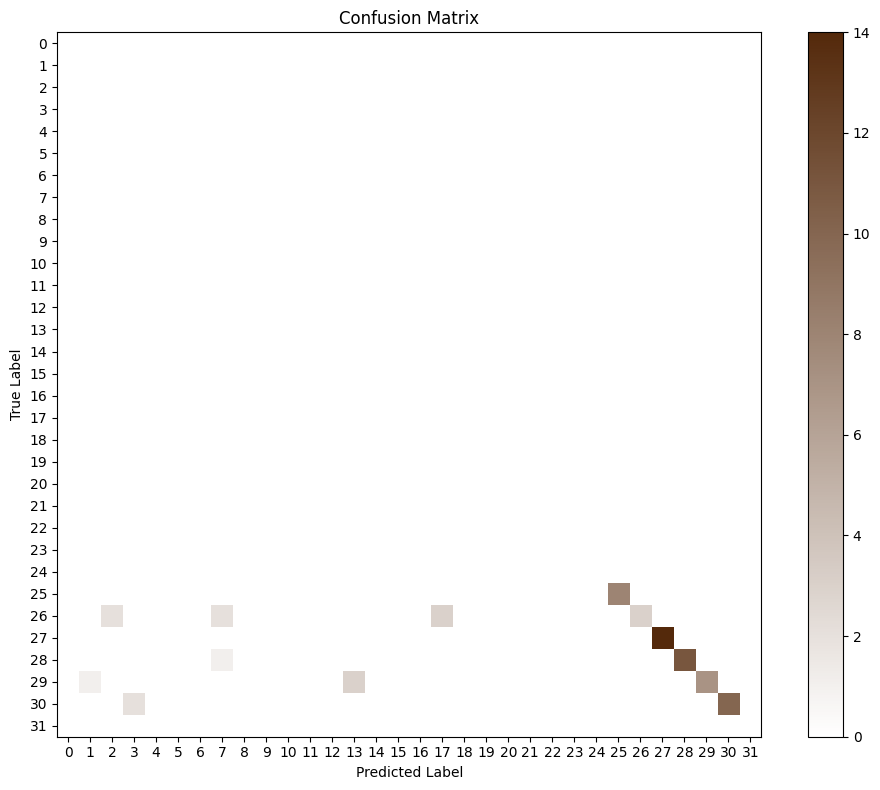

In [21]:
plot_confusion_matrix(model, test_loader)

In [49]:
# ! pip install captum

In [50]:
import torch
from captum.attr import IntegratedGradients

def explain_model_captum_full(model, dataloader, n_batches=None):
    model.eval()
    ig = IntegratedGradients(model)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    total_channel_importance = None
    total_step_importance = None
    total_features_heatmap = None
    samples_processed = 0

    for i, (x, y) in enumerate(dataloader):
        if n_batches and i >= n_batches:
            break
            
        x, y = x.to(device), y.to(device)
        x.requires_grad_()

        # attributions shape: (batch, input_size, seq_len)
        attributions = ig.attribute(x, target=y, n_steps=100).abs()

        # Importance per feature
        # Mean over seq_len, then sum over batch
        batch_channel = attributions.mean(dim=2).sum(dim=0)

        # Importance per time-step
        # Mean over input_size (channels), then sum over batch
        batch_steps = attributions.mean(dim=1).sum(dim=0)

        features_heatmap = attributions.sum(dim=0)

        if total_channel_importance is None:
            total_channel_importance = batch_channel.detach().cpu()
            total_step_importance = batch_steps.detach().cpu()
            total_features_heatmap = features_heatmap.detach().cpu()
        else:
            total_channel_importance += batch_channel.detach().cpu()
            total_step_importance += batch_steps.detach().cpu()
            total_features_heatmap += features_heatmap.detach().cpu()

        samples_processed += x.size(0)

    avg_channel_imp = (total_channel_importance / samples_processed).numpy()
    avg_step_imp = (total_step_importance / samples_processed).numpy()
    avg_features_heatmap = (total_features_heatmap / samples_processed).numpy()
    
    return avg_channel_imp, avg_step_imp, avg_features_heatmap

In [51]:
import matplotlib.pyplot as plt

def plot_feature_importance(importance_scores, feature_names=None):
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(len(importance_scores))]
    
    plt.figure(figsize=(7, 5))
    plt.barh(feature_names, importance_scores, color='skyblue')
    plt.xlabel("Mean Absolute Attribution (Importance)")
    plt.ylabel("Input Channels")
    plt.title("Global Feature Importance (Integrated Gradients)")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout() 
    plt.savefig('plots/explainable_elements/feature_importance_mocap.pdf')
    plt.show()

def plot_frame_importance(step_scores):
    plt.figure(figsize=(7, 5))
    plt.bar(list(range(32)), step_scores, color="orange", linewidth=2)
    
    plt.title("Temporal Importance (Integrated Gradients)")
    plt.xlabel("Frame")
    plt.ylabel("Mean Absolute Attribution (Importance)")
    plt.grid(True, alpha=0.3)
    plt.savefig('plots/explainable_elements/frame_importance_mocap.pdf')
    plt.show()


# def plot_frame_feature_heatmap(features_heatmap, feature_names=None):
#     plt.figure(figsize=(10, 4))
#     plt.imshow(features_heatmap, 
#                interpolation='nearest',
#                cmap=LinearSegmentedColormap.from_list(
#                    "brownish", ["white", "#54290b"]
#                ),
#     )
#     plt.title("Importance Heatmap (Integrated Gradients)")
#     plt.colorbar()
#     plt.xlabel("Frame")
#     plt.ylabel("Feature")
#     plt.savefig('plots/explainable_elements/importance_heatmap_mocap.pdf')
#     plt.show()

def plot_frame_feature_heatmap(features_heatmap, feature_names=None):
    plt.figure(figsize=(12, 4))
    plt.imshow(features_heatmap, 
               interpolation='nearest',
               aspect='auto', 
               cmap=LinearSegmentedColormap.from_list(
                   "brownish", ["white", "#54290b"]
               ),
    )
    if feature_names is not None:
        plt.yticks(range(len(feature_names)), feature_names)

    plt.title("Importance Heatmap (Integrated Gradients)")
    plt.colorbar()
    plt.xlabel("Frame")
    plt.ylabel("Feature")
    plt.tight_layout() 
    plt.savefig('plots/explainable_elements/importance_heatmap_mocap.pdf')
    plt.show()
    

In [52]:
feature_names = ['legs angle',
 'left knee angle',
 'right knee angle',
 'left hip angle',
 'right hip angle',
 'left humerus angle',
 'right humerus angle',
 'left elbow angle',
 'right elbow angle',
 'ankle distance',
 'knee distance',
 'elbow distance',
 'hand distance',
 'center of gravity height change',
 'lateral pelvic tilt',
 'pelvis rotation']

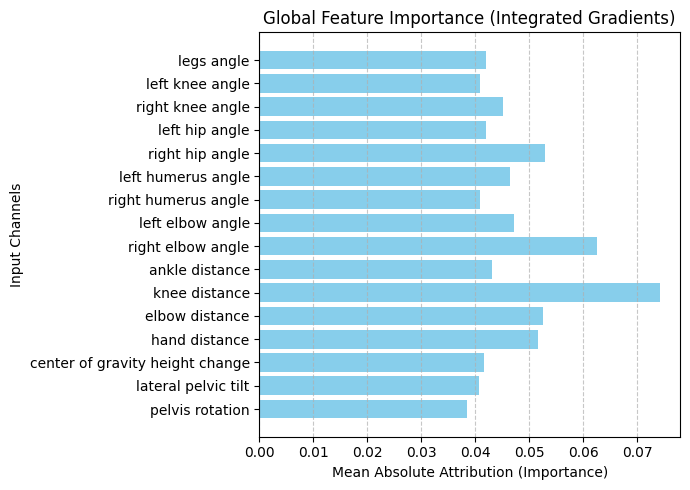

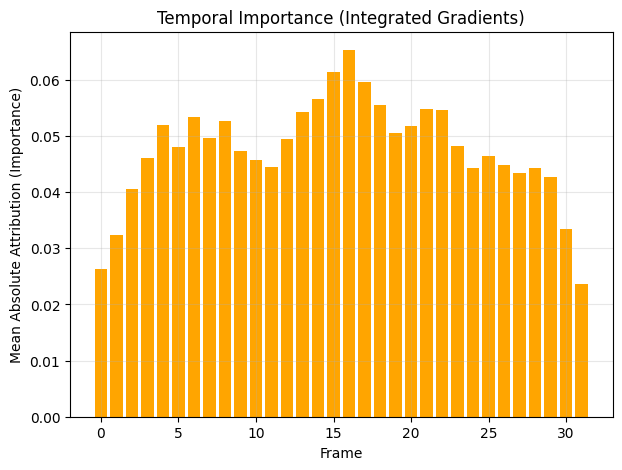

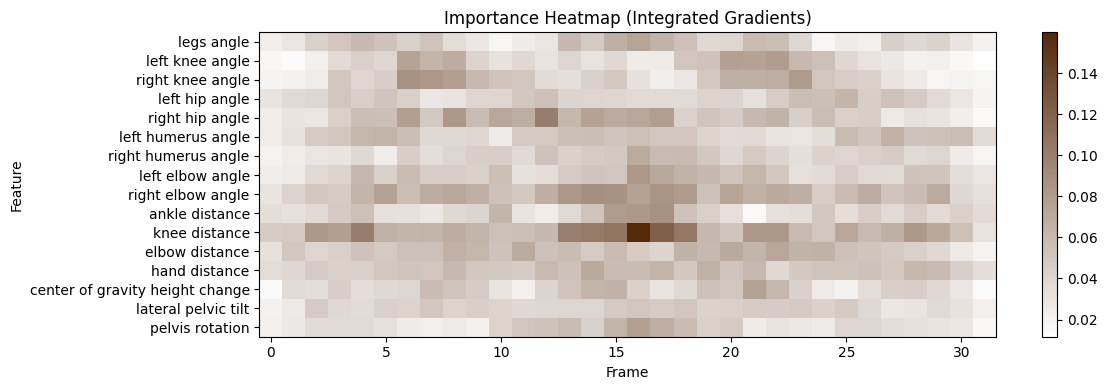

In [53]:
avg_channel_imp, avg_step_imp, avg_features_heatmap = explain_model_captum_full(model, test_loader)
plot_feature_importance(avg_channel_imp, feature_names)
plot_frame_importance(avg_step_imp)
plot_frame_feature_heatmap(avg_features_heatmap, feature_names)

In [228]:
cloth_1 = [1,2,3,4]
cloth_2 = [5,6,7,8]
num_epochs = 1000
learning_rate = 1e-4

datasets_results = {}

for dataset_name in datasets_parameters.keys():
    print(dataset_name)
    scaler = get_scaler_by_sequence(
        data_file = datasets_parameters[dataset_name],
        selected_sequences = cloth_1,
    )
    
    gd_cloth_1 = SiameseGaitDatasetSingle(
        selected_sequences = cloth_1,
        data_file = datasets_parameters[dataset_name],
        scaler = scaler,
    )
    
    gd_cloth_2 = SiameseGaitDatasetSingle(
        selected_sequences = cloth_2,
        data_file = datasets_parameters[dataset_name],
        scaler = scaler,
    )
    
    dataset = gd_cloth_1
    
    train_loader = DataLoader(
        gd_cloth_1,
        batch_size=32,
        shuffle=True,
    )
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ImprovedModel(input_size=16, num_classes=32)
    
    model = model.to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
    )
    
    val_ratio = 0.2
    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size
    
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    
    best_val_loss = float("inf")
    patience = 5
    counter = 0
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
    
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
    
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item()
    
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
    
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
    
        model.eval()
        val_loss = 0.0
    
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
    
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
    
        # print(
        #     f"Epoch [{epoch+1}/{num_epochs}] "
        #     f"Train Loss: {epoch_loss:.4f} "
        #     f"Train Acc: {epoch_acc:.4f} "
        #     f"Val Loss: {val_loss:.4f}"
        # )
    
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            # torch.save(model.state_dict(), "models/best_model_conv1d.pt")
        else:
            counter += 1
            if counter >= patience:
                break

    test_loader = DataLoader(
        gd_cloth_2,
        batch_size=32,
        shuffle=True,
    )

    evaluation_results = evaluate_topk(model, test_loader)
    print(evaluation_results)
    datasets_results[dataset_name] = evaluation_results
        

mocap
{1: 0.803030303030303, 2: 0.8333333333333334, 3: 0.8787878787878788}
openpose
{1: 0.765625, 2: 0.859375, 3: 0.921875}
mediapipe
{1: 0.45588235294117646, 2: 0.5735294117647058, 3: 0.6764705882352942}
hrnet
{1: 0.765625, 2: 0.859375, 3: 0.890625}
rtmpose
{1: 0.765625, 2: 0.84375, 3: 0.890625}
vitpose
{1: 0.796875, 2: 0.859375, 3: 0.921875}
movenet_lightning
{1: 0.25396825396825395, 2: 0.38095238095238093, 3: 0.47619047619047616}
movenet_thunder
{1: 0.1875, 2: 0.21875, 3: 0.234375}
yolo_v26
{1: 0.7611940298507462, 2: 0.8805970149253731, 3: 0.9253731343283582}
yolo_v11
{1: 0.796875, 2: 0.84375, 3: 0.90625}


In [229]:
datasets_results

{'mocap': {1: 0.803030303030303, 2: 0.8333333333333334, 3: 0.8787878787878788},
 'openpose': {1: 0.765625, 2: 0.859375, 3: 0.921875},
 'mediapipe': {1: 0.45588235294117646,
  2: 0.5735294117647058,
  3: 0.6764705882352942},
 'hrnet': {1: 0.765625, 2: 0.859375, 3: 0.890625},
 'rtmpose': {1: 0.765625, 2: 0.84375, 3: 0.890625},
 'vitpose': {1: 0.796875, 2: 0.859375, 3: 0.921875},
 'movenet_lightning': {1: 0.25396825396825395,
  2: 0.38095238095238093,
  3: 0.47619047619047616},
 'movenet_thunder': {1: 0.1875, 2: 0.21875, 3: 0.234375},
 'yolo_v26': {1: 0.7611940298507462,
  2: 0.8805970149253731,
  3: 0.9253731343283582},
 'yolo_v11': {1: 0.796875, 2: 0.84375, 3: 0.90625}}

In [251]:
print("      ", end="   &   ")
for estimator in datasets_results.keys():
    print(estimator, end="   &   ")
print("\\\\")
    
for i in range(1,4):
    print(f"rank-{i}", end="   &   ")
    for estimator in datasets_results.keys():
        print(round(datasets_results[estimator][i] * 100, 1), end="   &   ")
    print("\\\\")

        

         &   mocap   &   openpose   &   mediapipe   &   hrnet   &   rtmpose   &   vitpose   &   movenet_lightning   &   movenet_thunder   &   yolo_v26   &   yolo_v11   &   \\
rank-1   &   80.3   &   76.6   &   45.6   &   76.6   &   76.6   &   79.7   &   25.4   &   18.8   &   76.1   &   79.7   &   \\
rank-2   &   83.3   &   85.9   &   57.4   &   85.9   &   84.4   &   85.9   &   38.1   &   21.9   &   88.1   &   84.4   &   \\
rank-3   &   87.9   &   92.2   &   67.6   &   89.1   &   89.1   &   92.2   &   47.6   &   23.4   &   92.5   &   90.6   &   \\
